In [1]:
# Importing modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading ESOL data
esol_data_raw = pd.read_csv("data/ESOL.csv")[["smiles", "measured log solubility in mols per litre"]]
esol_data_raw = esol_data_raw.rename(columns={"measured log solubility in mols per litre":"target"})
esol_data_processed = pd.read_csv("data/processed/ESOL.csv")

# Loading Lipophilicity data
lipophil_data_raw = pd.read_csv("data/Lipophilicity.csv")[["smiles", "exp"]]
lipophil_data_raw = lipophil_data_raw.rename(columns={"exp":"target"})
lipophil_data_processed = pd.read_csv("data/processed/Lipophilicity.csv")

# Loading retention time (RT) data
rt_data_raw = pd.read_csv("data/RT.csv")
rt_data_raw = rt_data_raw.rename(columns={"SMILES":"smiles","RTs":"target"})
rt_data_processed = pd.read_csv("data/processed/RT.csv")

# Loading B3DB data
b3db_data_raw = pd.read_csv("data/B3DB.tsv", sep="\t")[["SMILES", "logBB"]]
b3db_data_raw = b3db_data_raw.rename(columns={"SMILES":"smiles", "logBB":"target"})
b3db_data_processed = pd.read_csv("data/processed/B3DB.csv")

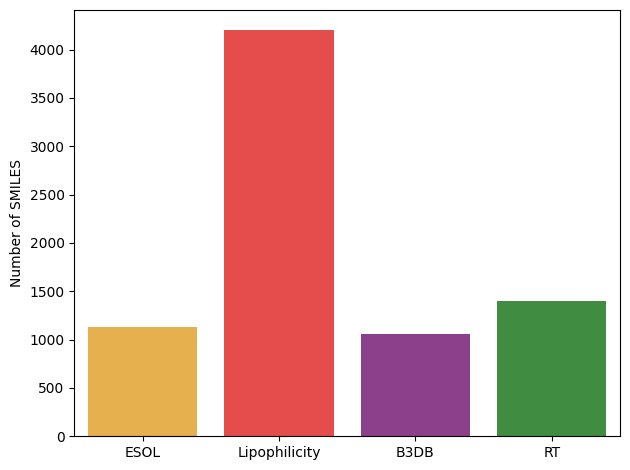

In [3]:
# Plot data
data = {"ESOL":len(esol_data_raw), "Lipophilicity":len(lipophil_data_raw), "B3DB":len(b3db_data_raw), "RT":len(rt_data_raw)}
df = pd.DataFrame(list(data.items()), columns=["Dataset", "Count"])
# Plot barplot
plt.figure(dpi=100)
palette = {"ESOL": "orange", "Lipophilicity":"red", "B3DB": "purple", "RT": "green"}
sns.barplot( x="Dataset", y="Count", data=df, hue="Dataset", palette=palette, alpha=0.8)
plt.ylabel("Number of SMILES")
plt.xlabel("")
plt.tight_layout()
plt.show()

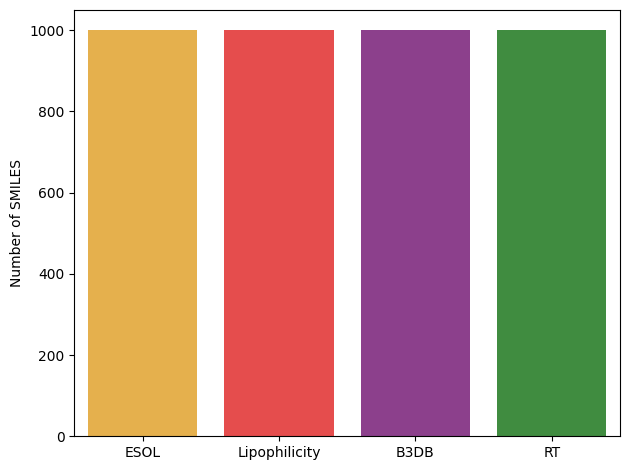

In [4]:
# Plot data
data = {"ESOL":len(esol_data_processed), "Lipophilicity":len(lipophil_data_processed), "B3DB":len(b3db_data_processed), "RT":len(rt_data_processed)}
df = pd.DataFrame(list(data.items()), columns=["Dataset", "Count"])
# Plot barplot
plt.figure(dpi=100)
palette = {"ESOL": "orange", "Lipophilicity":"red", "B3DB": "purple", "RT": "green"}
sns.barplot( x="Dataset", y="Count", data=df, hue="Dataset", palette=palette, alpha=0.8)
plt.ylabel("Number of SMILES")
plt.xlabel("")
plt.tight_layout()
plt.show()

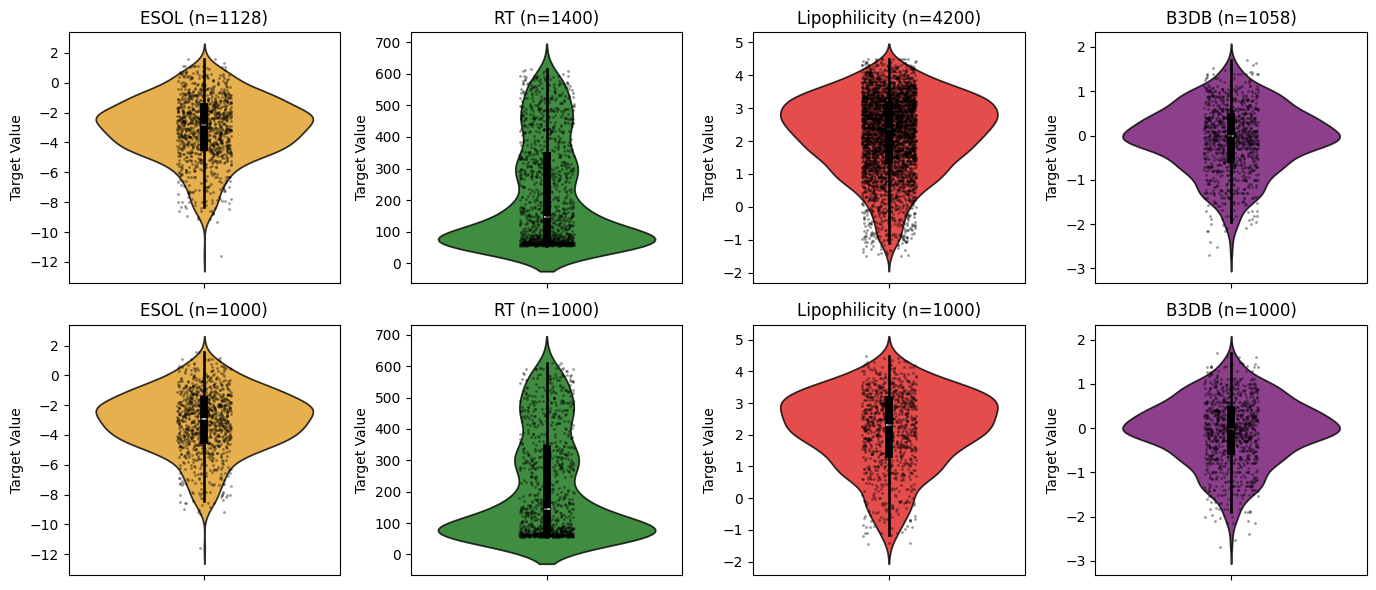

In [5]:
# Plot violin plot
fig, axes = plt.subplots(2, 4, dpi=100, figsize=(14, 6))
point_kws = dict(color="black", alpha=0.4, size=2)
def plot_violin(ax_raw, ax_proc, raw_data, proc_data, title, color):
    sns.violinplot(y=raw_data["target"], ax=ax_raw, color=color, linecolor="black", alpha=0.8)
    sns.stripplot(y=raw_data["target"], ax=ax_raw, **point_kws)
    ax_raw.set_title(f"{title} (n={len(raw_data)})")
    ax_raw.set_xlabel("")
    ax_raw.set_ylabel("Target Value")

    sns.violinplot(y=proc_data["target"], ax=ax_proc, color=color, linecolor="black", alpha=0.8)
    sns.stripplot(y=proc_data["target"], ax=ax_proc, **point_kws)
    ax_proc.set_title(f"{title} (n={len(proc_data)})")
    ax_proc.set_xlabel("")
    ax_proc.set_ylabel("Target Value")
ESOL_COL = 0
RT_COL = 1
LIPO_COL = 2
B3DB_COL = 3
plot_violin(axes[0, ESOL_COL], axes[1, ESOL_COL],
            esol_data_raw, esol_data_processed,
            "ESOL", "orange")
plot_violin(axes[0, RT_COL], axes[1, RT_COL],
            rt_data_raw, rt_data_processed,
            "RT", "green")
plot_violin(axes[0, LIPO_COL], axes[1, LIPO_COL],
            lipophil_data_raw, lipophil_data_processed,
            "Lipophilicity", "red")
plot_violin(axes[0, B3DB_COL], axes[1, B3DB_COL],
            b3db_data_raw, b3db_data_processed,
            "B3DB", "purple")
plt.tight_layout()
plt.show()